# Fitness Inspection

Small EDA notebook for comparing the completed `simple4`, `gecko4`, and `spider4` training runs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

RUNS = {
    "simple": Path("output/simple4/parameters_simple_run_20260605_162003.csv"),
    "gecko": Path("output/gecko4/parameters_gecko_run_20260605_161931.csv"),
    "spider": Path("output/spider4/parameters_spider_run_20260605_162017.csv"),
}

missing = [str(path) for path in RUNS.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing CSV files:\n" + "\n".join(missing))

dfs = {
    body: pd.read_csv(path)
    for body, path in RUNS.items()
}

for body, df in dfs.items():
    df["body"] = body
    df["num_of_generation"] = df["num_of_generation"].astype(int)

combined = pd.concat(dfs.values(), ignore_index=True)
combined.head()

,num_of_generation,best_fitness,worst_fitness,best_parent_fitness,best_offspring_fitness,best_ever_fitness,best_robot_weights,worst_robot_weights,body
0,0,0.174,0.000,NaN,NaN,0.174,"[0.9741603645318557, 0.6154204371114784, -0.74...","[0.9173349980184715, 0.01433041929015122, 0.54...",simple
1,1,0.174,0.000,0.174,0.174,0.174,"[0.9741603645318557, 0.6154204371114784, -0.74...","[0.7233787629160646, 0.12511154974001526, -0.7...",simple
2,2,0.174,0.006,0.174,0.174,0.174,"[0.9741603645318557, 0.6154204371114784, -0.74...","[-0.4318213466463139, -0.2821833759937542, 0.2...",simple
3,3,0.164,0.014,0.174,0.164,0.174,"[0.4281615832034036, 0.44750626736604393, -0.8...","[-0.5687535431361361, -0.6835233276170656, -0....",simple
4,4,0.172,0.018,0.164,0.172,0.174,"[0.4281615832034036, 0.44750626736604393, -0.8...","[0.8676531494546618, 0.7211232120551083, 0.963...",simple


## Quick Summary

In [2]:
summary_rows = []
for body, df in dfs.items():
    final = df.iloc[-1]
    best_idx = df["best_fitness"].idxmax()
    best = df.loc[best_idx]
    summary_rows.append(
        {
            "body": body,
            "generations": int(df["num_of_generation"].max()),
            "final_best_fitness": final["best_fitness"],
            "final_worst_fitness": final["worst_fitness"],
            "final_best_ever_fitness": final["best_ever_fitness"],
            "peak_current_best_fitness": best["best_fitness"],
            "peak_current_best_generation": int(best["num_of_generation"]),
        }
    )

summary = pd.DataFrame(summary_rows).set_index("body")
summary

,generations,final_best_fitness,final_worst_fitness,final_best_ever_fitness,peak_current_best_fitness,peak_current_best_generation
body,,,,,,
simple,100,0.234,0.158,0.250,0.250,30
gecko,100,0.118,0.000,0.118,0.118,30
spider,100,0.678,0.000,0.678,0.678,97


## Current Best Fitness

This is the best individual inside each generation, not necessarily the best ever retained across the whole run.

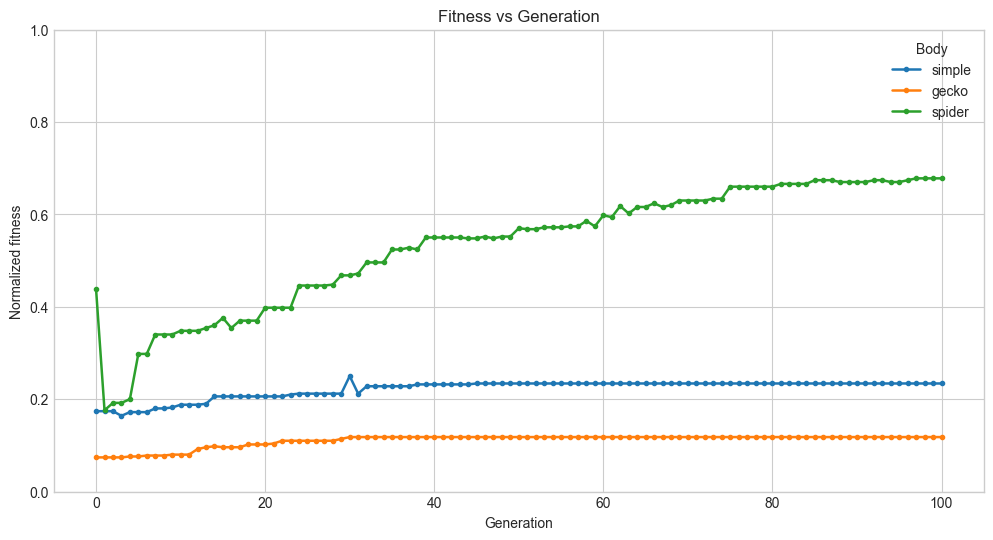

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

for body, df in dfs.items():
    ax.plot(
        df["num_of_generation"],
        df["best_fitness"],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=body,
    )

ax.set_title("Fitness vs Generation")
ax.set_xlabel("Generation")
ax.set_ylabel("Normalized fitness")
ax.set_ylim(0, 1)
ax.legend(title="Body")
plt.show()

## Current Worst Fitness

This shows whether the whole population is improving or whether only a few strong individuals are carrying the run.

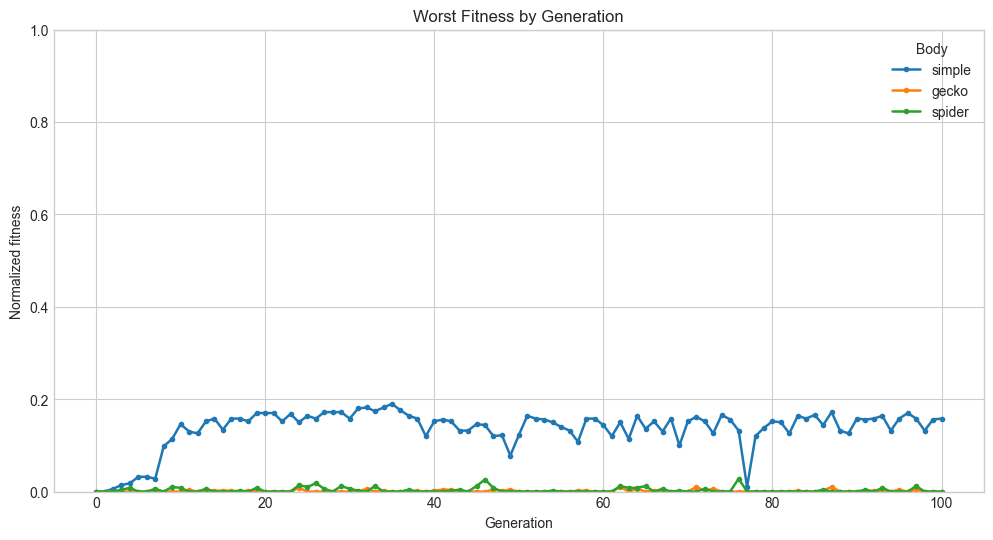

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

for body, df in dfs.items():
    ax.plot(
        df["num_of_generation"],
        df["worst_fitness"],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=body,
    )

ax.set_title("Worst Fitness by Generation")
ax.set_xlabel("Generation")
ax.set_ylabel("Normalized fitness")
ax.set_ylim(0, 1)
ax.legend(title="Body")
plt.show()

## Best-Ever Fitness

This is the running best retained by the EA. In runs without elitism, this can differ from the current generation's best.

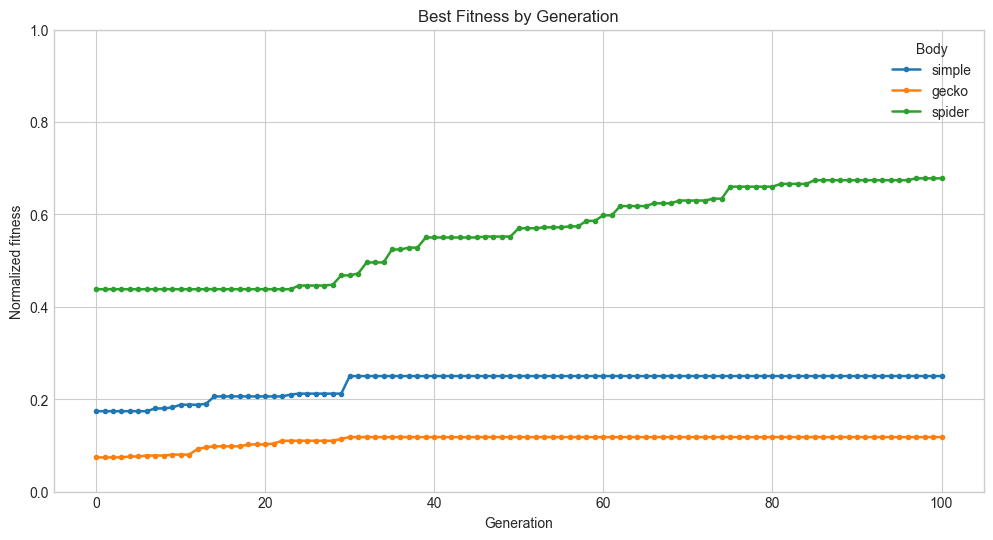

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

for body, df in dfs.items():
    ax.plot(
        df["num_of_generation"],
        df["best_ever_fitness"],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=body,
    )

ax.set_title("Best Fitness by Generation")
ax.set_xlabel("Generation")
ax.set_ylabel("Normalized fitness")
ax.set_ylim(0, 1)
ax.legend(title="Body")
plt.show()

## Parent vs Offspring Best

Useful for checking whether new children are actually beating the previous generation.

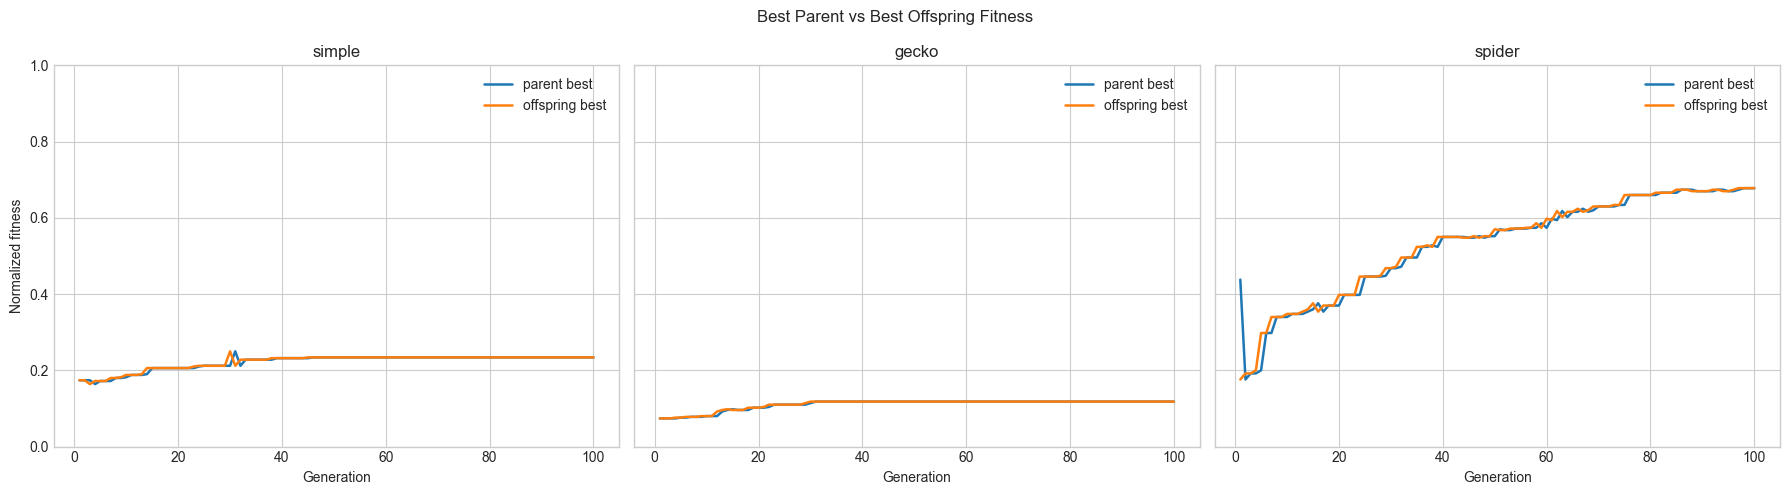

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (body, df) in zip(axes, dfs.items()):
    ax.plot(
        df["num_of_generation"],
        df["best_parent_fitness"],
        linewidth=1.8,
        label="parent best",
    )
    ax.plot(
        df["num_of_generation"],
        df["best_offspring_fitness"],
        linewidth=1.8,
        label="offspring best",
    )
    ax.set_title(body)
    ax.set_xlabel("Generation")
    ax.set_ylim(0, 1)
    ax.legend()

axes[0].set_ylabel("Normalized fitness")
fig.suptitle("Best Parent vs Best Offspring Fitness")
plt.tight_layout()
plt.show()